# Post-2000 Vaccination Counterfactual Experiments

This notebook runs counterfactual experiments starting from the shared 2000 particle cloud.

By 2020, measles in Texas was functionally extinct with zero reported cases for multiple years, and the calibrated model matches this behavior. Dynamics during the experimental window thus are driven only by the importation of infected individuals' mechanism present in all runs of the model. Modeling the migration of infected individuals into the population like travelers that actually drives modern outbreaks in a post extinction era, the model produces an expected value of 3 cases per year. These experiments therefore are primarily measuring how counterfactual vaccination schedules and rates can allow this background importation of cases to spark into epidemics above the importation noise. 

## Summary

Scenarios of delayed vaccination later than the CDC recommended schedule leads to measles cases above the importation floor in all modeled experiments. Vaccinating the majority of children at age 3 causes moderate outbreaks and vaccinating only at the required school age of 5 leads to pre-vaccine levels of cases. Using these simulations, we can expect that if the delayed vaccination movement continues to proliferate measles cases will see moderate to substantial increases.

In [32]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from src.utils import load_config
from src.data import contact_matrix
from src.data import historical_population
from src.experiments import counterfactuals
from src.model import stochastic_model

config = load_config()

CALIBRATION_RESULT = Path(config['paths']['data_processed_dir']) / 'stochastic_calibration_result.json'
VALIDATION_RESULT = Path(config['paths']['data_processed_dir']) / 'stochastic_validation_result.json'
CLOUD_PATH = Path(config['paths']['data_processed_dir']) / 'stochastic_validation_final_cloud.npz'

EXPERIMENTAL_END_YEAR = 2025.0
STEP_YEARS = 1.0 / 52.1775


In [19]:
with open(CALIBRATION_RESULT) as f:
    calibration = json.load(f)
with open(VALIDATION_RESULT) as f:
    val = json.load(f)

experimental_start_year = float(val['validation_window']['end'][:4])
assert np.isclose(experimental_start_year, counterfactuals.BRANCH_YEAR), 'Branch point must be 2000.'

cloud_npz = np.load(CLOUD_PATH)
cloud_2000 = stochastic_model.StochasticParticleCloud(
    t=float(np.asarray(cloud_npz['t'])),
    counts=np.asarray(cloud_npz['counts'], dtype=np.int64),
)

theta_hat = calibration['theta_hat']
birth_rate, death_rate = historical_population.build_vital_rate_functions()
contact_df = contact_matrix.load_processed_contact_matrix(config)
fixed_parameters = {
    'gamma': config['calibration']['calibration_fixed_parameters']['gamma'],
    'sigma': config['calibration']['calibration_fixed_parameters']['sigma'],
    'maternal_waning_rate': config['calibration']['calibration_fixed_parameters']['maternal_waning_rate'],
    'birth_rate': birth_rate,
    'death_rate': death_rate,
    'contact_matrix': contact_df.to_numpy(dtype=float),
}

calendar_years = np.arange(
    experimental_start_year,
    EXPERIMENTAL_END_YEAR + STEP_YEARS / 2,
    STEP_YEARS,
)
if calendar_years[-1] < EXPERIMENTAL_END_YEAR:
    calendar_years = np.r_[calendar_years, EXPERIMENTAL_END_YEAR]

scenario_results: dict[str, counterfactuals.CounterfactualResult] = {}


In [20]:
def _vaccination_channel_label(channel_idx: int, age_group_labels: list[str]) -> str:
    '''convert index to legible age group'''
    return f'{age_group_labels[channel_idx]} → {age_group_labels[channel_idx + 1]}'


def run_and_plot_experiment(
    experiment_name: str,
    initial_cloud: stochastic_model.StochasticParticleCloud,
    theta_hat: dict,
    fixed_parameters: dict,
    calendar_years: np.ndarray,
    seed: int = 123,
) -> counterfactuals.CounterfactualResult:
    '''Run a named scenario from counterfactuals.EXPERIMENTS and render coverage & simulation plots.'''
    if experiment_name not in counterfactuals.EXPERIMENTS:
        available = ', '.join(counterfactuals.EXPERIMENTS.keys())
        raise ValueError(f'unknown experiment')

    schedule_fn = counterfactuals.EXPERIMENTS[experiment_name]
    rng = np.random.default_rng(seed)

    result = counterfactuals.run_branch(
        scenario=experiment_name,
        initial_cloud=initial_cloud,
        theta_hat=theta_hat,
        fixed_parameters=fixed_parameters,
        calendar_years=calendar_years,
        rng=rng,
    )

    scenario_results[experiment_name] = result

    rates = np.stack([schedule_fn(y) for y in calendar_years], axis=0)
    n_channels = rates.shape[1]
    age_group_labels = counterfactuals.config['age_structure']['age_group_labels']

    fig, ax = plt.subplots(figsize=(9, 3.5))
    for channel_idx in range(n_channels):
        label = _vaccination_channel_label(channel_idx, age_group_labels)
        ax.plot(calendar_years, rates[:, channel_idx], label=label)
    ax.set_xlabel('Calendar year')
    ax.set_ylabel('Coverage')
    ax.set_title(f'{experiment_name}: vaccination coverage schedule')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()

    interval_years = result.calendar_years[1:]
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.fill_between(
        interval_years,
        result.simulated_case_counts_ci[:, 0],
        result.simulated_case_counts_ci[:, 1],
        color='tab:blue',
        alpha=0.25,
        label='Posterior-predictive 5-95% band',
    )
    ax.plot(
        interval_years,
        result.simulated_case_counts_mean,
        color='tab:blue',
        lw=1.5,
        label='Posterior-predictive mean',
    )

    ax.set_xlabel('Calendar year')
    ax.set_ylabel('Reported cases / interval')
    ax.set_title(f'{experiment_name}: forward simulation')
    ax.legend(loc='upper right', fontsize=9)
    fig.tight_layout()
    plt.show()

    return result

### Statistical Tests

In [ ]:
def _holm_bonferroni(pvalues: list[float]) -> list[float]:
    '''applies the Holm-Bonferroni step-down correction to a list of p-values

    preferred over a plain Bonferroni correction here since it controls the same
    family wise error rate while being uniformly more powerful.

    Parameters
    ----------
    pvalues : list[float]
        raw p-values, one per hypothesis test in the family

    Returns
    -------
    list[float]
        adjusted p-values in the same order as pvalues, each clipped to at most 1.0
    '''
    n = len(pvalues)
    order = np.argsort(pvalues)
    adjusted = np.empty(n)
    running_max = 0.0
    for rank, idx in enumerate(order):
        candidate = (n - rank) * pvalues[idx]
        running_max = max(running_max, candidate)
        adjusted[idx] = min(running_max, 1.0)
    return adjusted.tolist()


def paired_comparison(cumulative_by_scenario: dict, scenario_a: str, scenario_b: str, rng: np.random.Generator, n_resamples: int = 200000) -> dict:
    '''runs a paired sign-flip permutation test comparing two scenarios' cumulative case counts

    particles are paired across scenarios via the common seed used when each scenario
    was branched. A sign-flip permutation test on the mean difference is used because c
    umulative case counts are right skewed or overdispersed

    Parameters
    ----------
    cumulative_by_scenario : dict
        scenario name -> np.ndarray of shape (n_particles,) cumulative case counts,
        as built in the Summary Statistics section.
    scenario_a : str
        first scenario name
    scenario_b : str
        second scenario name
    rng : np.random.Generator
        drives the permutation resampling.
    n_resamples : int
        number of sign-flip resamples, by default 20000.

    Returns
    -------
    dict
        scenario_a, scenario_b, n_particles, mean_diff (scenario_a - scenario_b),
        statistic, p_value. All fields but scenario_a/scenario_b/n_particles are nan
        if n_particles < 2.

    Raises
    ------
    ValueError
        scenario_a and scenario_b have mismatched particle counts and so cannot be paired.
    '''
    a = cumulative_by_scenario[scenario_a]
    b = cumulative_by_scenario[scenario_b]
    if len(a) != len(b):
        raise ValueError(f'{scenario_a!r} and {scenario_b!r} have mismatched particle counts -- cannot pair them.')

    n_particles = len(a)
    diff = a - b
    result = {'scenario_a': scenario_a, 'scenario_b': scenario_b, 'n_particles': n_particles, 'mean_diff': float(diff.mean())}

    if n_particles < 2:
        result.update(statistic=float('nan'), p_value=float('nan'))
        return result

    def mean_stat(d, axis=-1):
        return np.mean(d, axis=axis)

    res = stats.permutation_test(
        (diff,),
        mean_stat,
        permutation_type='samples',
        alternative='two-sided',
        n_resamples=n_resamples,
    )
    result['statistic'] = float(res.statistic)
    result['p_value'] = float(res.pvalue)
    return result

In [21]:
print('Available experiments:', list(counterfactuals.EXPERIMENTS.keys()))

Available experiments: ['continued_high_coverage', 'delayed_schedule', 'only_school_age', 'coverage_decline']


## Continued High Coverage at Pre-2020 Levels
Baseline experiment, maintaining high coverage levels

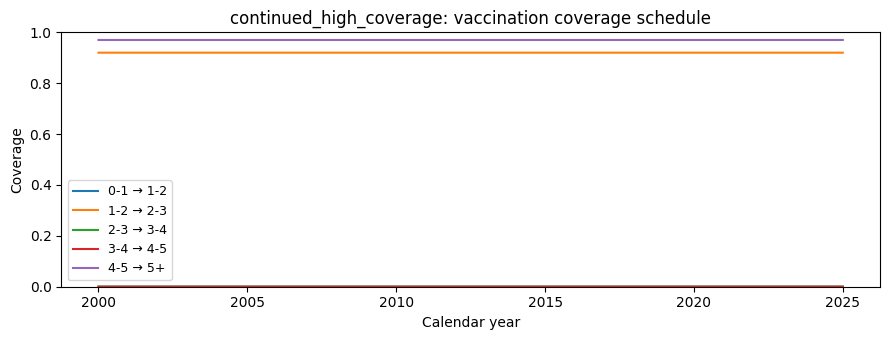

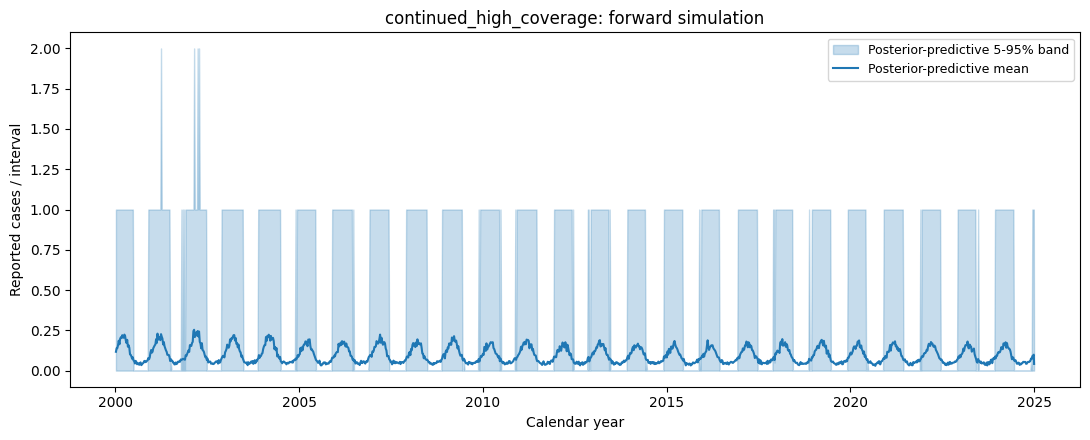

In [22]:
result = run_and_plot_experiment(
    experiment_name='continued_high_coverage',
    initial_cloud=cloud_2000,
    theta_hat=theta_hat,
    fixed_parameters=fixed_parameters,
    calendar_years=calendar_years,
    seed=123,
)


The reported cases stay almost exactly at the noise floor, as expected. Even with background importation, high vaccination coverage across age groups keeps susceptible populations low, minimizing transmission rates.

## Delayed Schedule

The principle experiment. While the CDC recommends vaccinating children for MMR at age one, some alternate schedules propose waiting to vaccinate for MMR until age 3-4. This experiment models a scenario where a majority of individuals follow this alternate schedule rather than the CDC recommended one by setting a small vaccination rate at the recommended 0-1 boundary but a higher proportion at 3-4. 

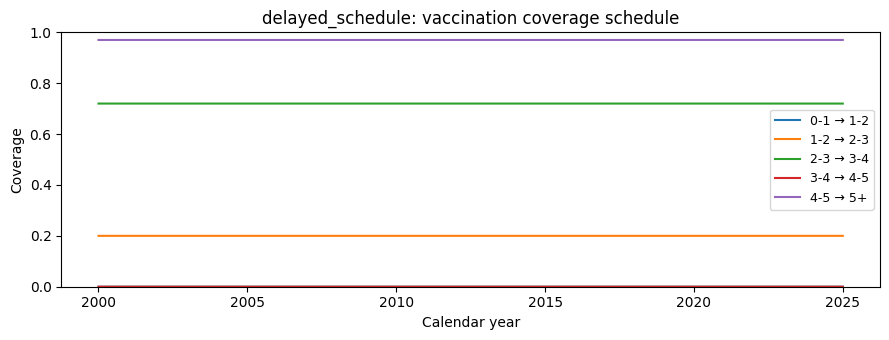

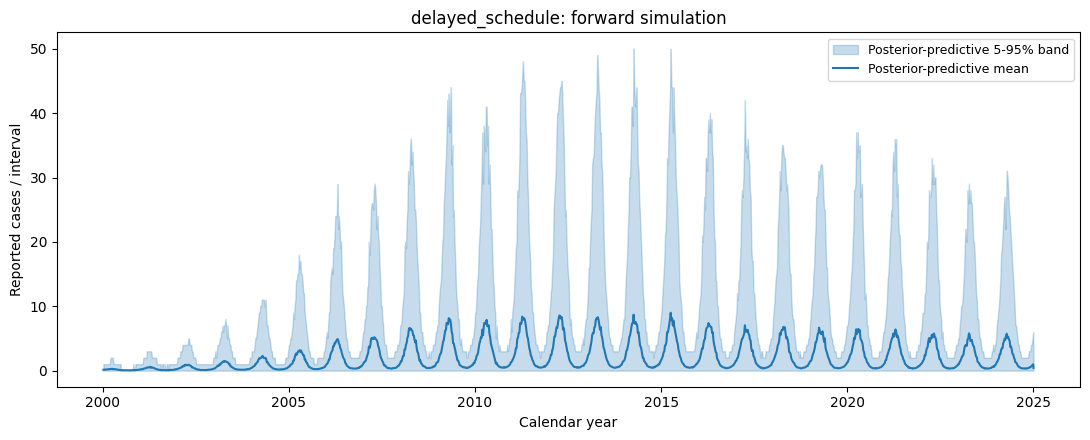

In [23]:
result = run_and_plot_experiment(
    experiment_name='delayed_schedule',
    initial_cloud=cloud_2000,
    theta_hat=theta_hat,
    fixed_parameters=fixed_parameters,
    calendar_years=calendar_years,
    seed=123,
)

Decreasing the rate at which young children are vaccinated pushes the reported cases significantly above the importation floor, likely because delayed vaccination allows a susceptible population to build up at the younger age groups which is then sparked by importation. 

## School Age Only

This experiment pushes even further into the counterfactual, modeling a scenario where the majority of kids are only vaccinated once they reach school age at 5 years old, when MMR vaccination is required by all public schools for entry into kindergarten. This experiment maintains a small vaccination rate at the recommended boundary.

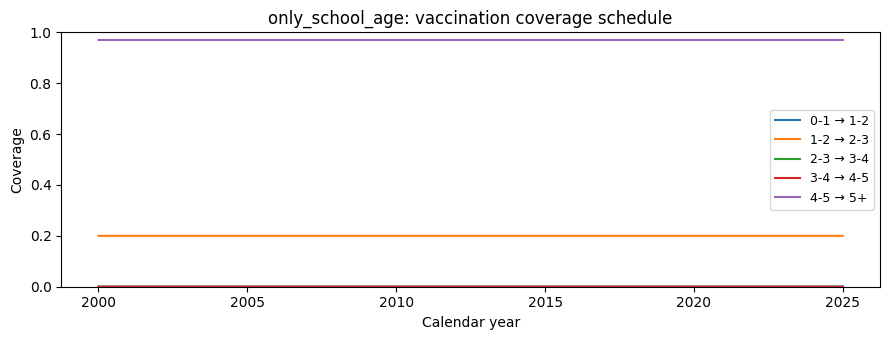

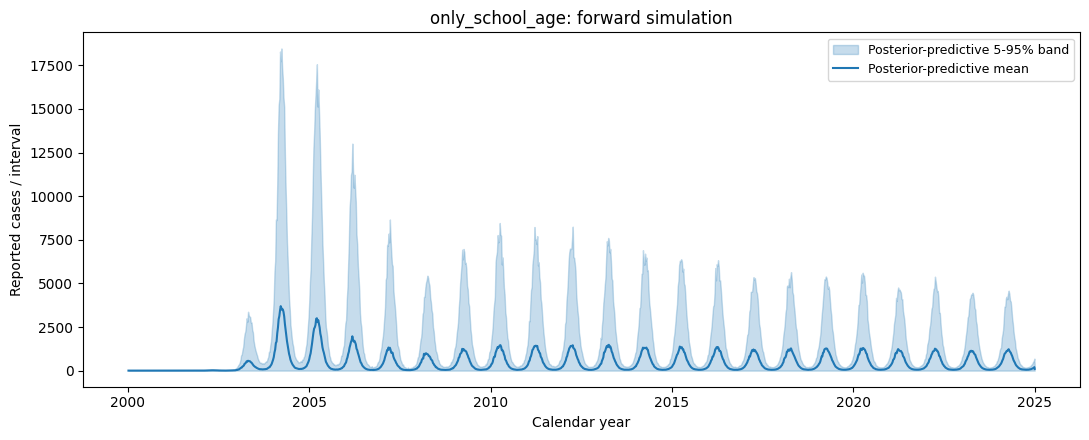

In [24]:
result = run_and_plot_experiment(
    experiment_name='only_school_age',
    initial_cloud=cloud_2000,
    theta_hat=theta_hat,
    fixed_parameters=fixed_parameters,
    calendar_years=calendar_years,
    seed=123,
)

Delaying vaccination to the latest possible for the majority of children cases outbreaks to explode to pre vaccine levels, reflecting how measles is primarily a childhood infection affecting those under 5. It visually seems to take a few years for importation to cause a spark in the building susceptible population before exploding and then returning to a non-zero endemic equilibrium.

## Summary Statistics

Compute summary statistics for all experiments, then run a paired sign flip permutation test to compare the mean cumulative cases for both experiments compared to the high vaccination baseline. Samples are paired because every simulation is run with the same random seed, so particle $i$ in both simulations shares the same random draws up to the vaccination treatment. A sign flip permutation test is appropriate because the particle clouds are not normally distributed and because we are specifically testing the mean. Holms-Bonferroni correction is applied to account for false positive rates in repeated tests

In [31]:
summary_rows = []
cumulative_by_scenario = {}

for scenario_name, result in scenario_results.items():
    cumulative = result.simulated_case_draws.sum(axis=1) # (P,)
    cumulative_by_scenario[scenario_name] = cumulative
    summary_rows.append({
        'scenario': scenario_name,
        'mean_cumulative_cases': cumulative.mean(),
        'median_cumulative_cases': np.median(cumulative),
        'p05': np.percentile(cumulative, 5),
        'p95': np.percentile(cumulative, 95),
    })

summary_df = pd.DataFrame(summary_rows).set_index('scenario')
summary_df

,mean_cumulative_cases,median_cumulative_cases,p05,p95
scenario,,,,
continued_high_coverage,125.2585,118.0,62.00,215.00
delayed_schedule,2697.7810,1079.0,166.95,11015.70
only_school_age,572617.7665,586802.0,402723.20,688577.00
coverage_decline,126.9455,117.0,65.00,219.05


In [36]:
BASELINE_SCENARIO = 'continued_high_coverage'
COMPARISON_SCENARIOS = ['delayed_schedule', 'only_school_age']

rng_test = np.random.default_rng(2024)
test_rows = [
    paired_comparison(cumulative_by_scenario, scenario_name, BASELINE_SCENARIO, rng_test)
    for scenario_name in COMPARISON_SCENARIOS
]

test_df = pd.DataFrame(test_rows).set_index('scenario_a')
test_df['p_value_holm'] = _holm_bonferroni(test_df['p_value'].tolist())
test_df['reject_at_0.05'] = test_df['p_value_holm'] < 0.05

test_df

,scenario_b,n_particles,mean_diff,statistic,p_value,p_value_holm,reject_at_0.05
scenario_a,,,,,,,
delayed_schedule,continued_high_coverage,2000,2572.5225,2572.5225,0.0001,0.0002,True
only_school_age,continued_high_coverage,2000,572492.5080,572492.5080,0.0001,0.0002,True


The tests confirm that both simulations represent statistically significant evidence that the experiments vary from the baseline at the cumulative level, with corrected p values passing the majority of significance levels.

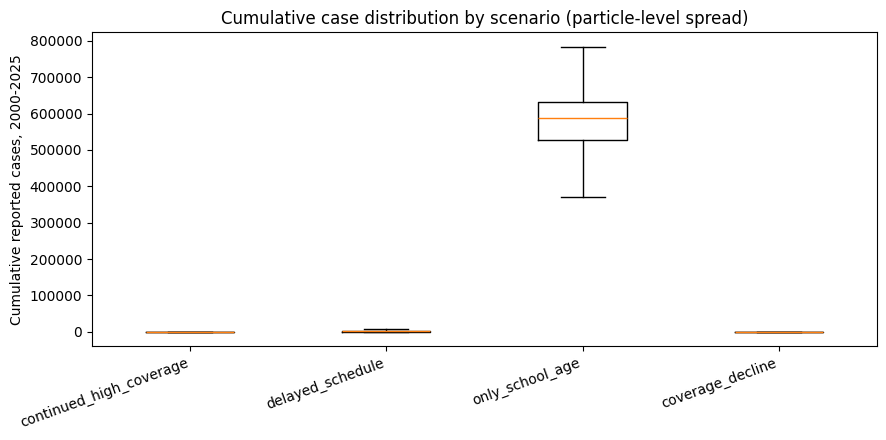

In [27]:
fig, ax = plt.subplots(figsize=(9, 4.5))
scenario_names = list(cumulative_by_scenario.keys())
ax.boxplot(
    [cumulative_by_scenario[s] for s in scenario_names],
    tick_labels=scenario_names,
    showfliers=False,
)
ax.set_ylabel('Cumulative reported cases, 2000-2025')
ax.set_title('Cumulative case distribution by scenario (particle-level spread)')
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
fig.tight_layout()
plt.show()

Box plot visually shows only school age exceeding both other scenarios by oders of magnitude

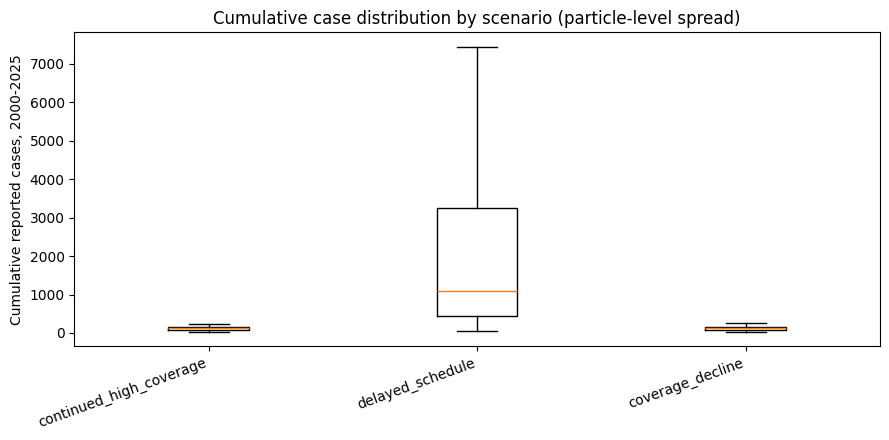

In [28]:
fig, ax = plt.subplots(figsize=(9, 4.5))
reduced_scenario_names = [s for s in list(cumulative_by_scenario.keys()) if s != 'only_school_age' ]
ax.boxplot(
    [cumulative_by_scenario[s] for s in reduced_scenario_names],
    tick_labels=reduced_scenario_names,
    showfliers=False,
)
ax.set_ylabel('Cumulative reported cases, 2000-2025')
ax.set_title('Cumulative case distribution by scenario (particle-level spread)')
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
fig.tight_layout()
plt.show()

Removing school age for resultion, we see that the delayed schedule also estimates more cases by orders of magnitude, though the lowest estimates for the delayed schedule are more in line with other scenarios

## Paired Simulation Comparisons

In [29]:
BASELINE_SCENARIO = 'continued_high_coverage'

pairwise_rows = []
for scenario_name in scenario_names:
    if scenario_name == BASELINE_SCENARIO:
        continue
    diff = cumulative_by_scenario[scenario_name] - cumulative_by_scenario[BASELINE_SCENARIO]
    pairwise_rows.append({
        'scenario': scenario_name,
        'vs_baseline': BASELINE_SCENARIO,
        'mean_excess_cases': diff.mean(),
        'excess_cases_5_95_ci': (float(np.percentile(diff, 5)), float(np.percentile(diff, 95))),
        'P(worse than baseline)': float((diff > 0).mean()),
    })

pairwise_df = pd.DataFrame(pairwise_rows).set_index('scenario')
pairwise_df

,vs_baseline,mean_excess_cases,excess_cases_5_95_ci,P(worse than baseline)
scenario,,,,
delayed_schedule,continued_high_coverage,2572.5225,"(40.95, 10817.949999999999)",0.9700
only_school_age,continued_high_coverage,572492.5080,"(402576.3, 688461.3)",1.0000
coverage_decline,continued_high_coverage,1.6870,"(-54.05, 62.049999999999955)",0.4945


Comparing the simulations directly on a particle by particle basis, again note the extreme difference in cases between all simulations and the baseline. Computing the probability that a scenario has more cases than the baseline naively for just this simulation, the delayed schedule has more cases 97% of the time and the only school age schedule always has more cases.

## Sensitivity Sweep

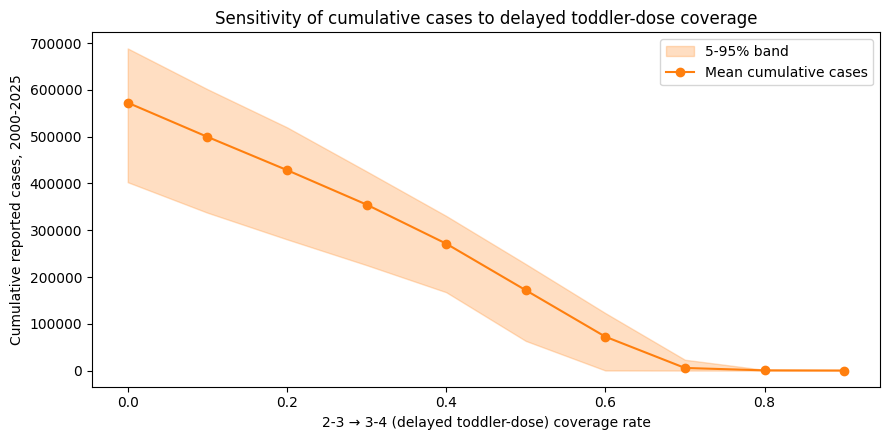

,channel_rate,mean_cumulative_cases,p05,p95
0,0.0,572617.7665,402723.20,688577.00
1,0.1,499693.2470,337624.80,601599.60
2,0.2,428668.7580,280629.25,520110.60
3,0.3,354910.0950,225510.80,426025.95
4,0.4,271446.5020,167666.70,330754.80
5,0.5,171928.1120,63574.05,227897.25
6,0.6,72556.8405,370.95,123016.75
7,0.7,5759.8220,192.00,23285.65
8,0.8,633.7810,127.00,1716.80
9,0.9,303.0690,95.00,674.00


In [37]:
DELAYED_ON_TIME_COVERAGE = 0.2
SCHOOL_ENTRY_COVERAGE = 0.97
SWEEP_CHANNEL = counterfactuals.TODDLER_DOSE_CHANNEL + 1
SWEEP_RATES = np.linspace(0.0, 0.9, 10)

def _swept_schedule(channel_rate: float):
    '''constant schedule with a swept 2-3->3-4 coverage, other channels held fixed'''
    def schedule(calendar_year: float) -> np.ndarray:
        rates = np.zeros(config['age_structure']['n_vaccination_rates'], dtype=float)
        rates[counterfactuals.TODDLER_DOSE_CHANNEL] = DELAYED_ON_TIME_COVERAGE
        rates[SWEEP_CHANNEL] = channel_rate
        rates[counterfactuals.SCHOOL_ENTRY_CHANNEL] = SCHOOL_ENTRY_COVERAGE
        return rates
    return schedule

sweep_rows = []
for rate in SWEEP_RATES:
    temp_name = f'_sweep_{SWEEP_CHANNEL}_{rate:.3f}'
    counterfactuals.EXPERIMENTS[temp_name] = _swept_schedule(rate)
    try:
        rng = np.random.default_rng(123)
        result = counterfactuals.run_branch(
            scenario=temp_name,
            initial_cloud=cloud_2000,
            theta_hat=theta_hat,
            fixed_parameters=fixed_parameters,
            calendar_years=calendar_years,
            rng=rng,
        )
        cumulative = result.simulated_case_draws.sum(axis=1)
        sweep_rows.append({
            'channel_rate': rate,
            'mean_cumulative_cases': cumulative.mean(),
            'p05': np.percentile(cumulative, 5),
            'p95': np.percentile(cumulative, 95),
        })
    finally:
        del counterfactuals.EXPERIMENTS[temp_name]

sweep_df = pd.DataFrame(sweep_rows)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.fill_between(
    sweep_df['channel_rate'], sweep_df['p05'], sweep_df['p95'],
    color='tab:orange', alpha=0.25, label='5-95% band',
)
ax.plot(
    sweep_df['channel_rate'], sweep_df['mean_cumulative_cases'],
    color='tab:orange', marker='o', lw=1.5, label='Mean cumulative cases',
)
ax.set_xlabel('2-3 → 3-4 (delayed toddler-dose) coverage rate')
ax.set_ylabel('Cumulative reported cases, 2000-2025')
ax.set_title('Sensitivity of cumulative cases to delayed toddler-dose coverage')
ax.legend()
fig.tight_layout()
plt.show()

sweep_df

A sensitivity sweep over the delayed toddler dose rate demonstrates that even at 90% vaccination coverage mean cumulative cases are meaningfully above the extinction level, with the 5th percentile still reporting 95 cases in 5 years or 18 cases average per year. In this simulation, delayed vaccination at any reasonable level leads to outbreaks that do not occur when vaccination occurs at the recommended age. Widespread uptake of this delayed vaccination schedule could meaningfully increase measles outbreaks.